In [ ]:
import re
import warnings
from collections import defaultdict
from math import ceil
from pathlib import Path
from typing import Any, Literal

import marimo as mo
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import numpy as np
import polars as pl
import seaborn as sns
from bson import BSON
from matplotlib import ticker
from upsetplot import UpSet, from_contents

# Manuscript figures
This notebook contains code to plot all figures in the MetaHQ manuscript.

Author: Parker Hicks <br>
Date: 2026-01-17 <br>
Last updated: 2026-05-27 by Parker Hicks

In [ ]:
def load_bson(file: Path | str, **kwargs) -> dict[str, Any]:
    """Load dictionary from compressed bson."""
    with open(file, "rb") as bf:
        return BSON(bf.read()).decode(**kwargs)

def load_txt(file: Path | str, **kwargs) -> list[str]:
    """Load txt file."""
    with open(file, "r", **kwargs) as f:
        return [line.strip() for line in f.readlines()]

In [ ]:
# constants
ANNOTATIONS_DIR = Path("data/processed")
ATTRIBUTES = ["tissue", "disease", "sex", "age"]

METADATA_DIR = Path("data/metadata")
PLATFORMS_FILE = METADATA_DIR / "technologies.parquet"

RESULTS_DIR: Path = Path("results")
UNIQUE_PROPAGATED_TERMS: Path = RESULTS_DIR / "unique_propagated_tissue_disease_terms.txt"
OVERLAP_RESULTS = list(RESULTS_DIR.glob("overlap*"))

FIGURES_DIR: Path = Path("figures")

## Source annotation files
PROCESSED_DIR = Path("data/processed")
SRA_PROCESSED = PROCESSED_DIR / "sra_combined.bson"
GEO_PROCESSED = PROCESSED_DIR / "geo_combined.bson"
SEMI_PROCESSED_SERIES = Path("data/analysis/semi_processed__combined__level-series.bson")

## helpers
SRA2GEO = Path("data/metadata/sra2geo.parquet")

ATTRIBUTES = ["tissue", "disease", "sex", "age"]

## plotting
COLORS = {'tissue': 'steelblue', 'disease': 'coral', 'sex': 'mediumseagreen', 'age': 'mediumpurple'}
FMT = "png"
OVERLAP_ORDER = ["tissue", "disease", "sex", "age"]
OVERLAP_CMAP = "Blues"
PMI_CMAP = "vlag"

In [ ]:
# load the databases
sample_db = load_bson(ANNOTATIONS_DIR / "combined__level-sample.bson")
series_db = load_bson(ANNOTATIONS_DIR / "combined__level-series.bson")

print("Number of entries in MetaHQ:")
print(f"Samples: {len(sample_db)}")
print(f"Studies: {len(series_db)}")

Number of entries in MetaHQ:
Samples: 190175
Studies: 19723


# Plot total annotations for each attribute

In [ ]:
def plot_total_anno_sample_and_study(
    sample_data: dict,
    study_data: dict,
    attributes: list[str],
    ylabel: str,
    figsize: tuple[int, int]=(5,5),
    save: bool=False,
    outfile: str | Path | None = None,
    dpi: int = 600,
    verbose: bool = False,
    titles: list[str] | None = None,
    order: list[str] | None = None,
    ylim_scale: int = 1,
):
    """Plot the total number of entries with each attribute annotation."""
    colors = {k.capitalize(): v for k,v in COLORS.items()}

    dfs = []
    # count attribute anntotations
    for data in [sample_data, study_data]:
        total = {attribute: 0 for attribute in attributes}
        for anno in data.values():
            for attribute in attributes:
                if attribute in anno:
                    total[attribute] += 1

        df = pl.DataFrame(
                {"attribute": list(total.keys()), "count": list(total.values())}
        )

        df = (
            df
                .with_columns(
                    pl.col("attribute").str.to_titlecase().alias("attribute")
                )
        )
        dfs.append(df)

    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)
    for idx, (df, ax) in enumerate(zip(dfs, axes)):
        sns.barplot(
            df, 
            y="attribute",
            x="count",
            hue="attribute", 
            palette=colors, 
            ax=ax,
            legend=False,
            order=order,
        )

        ax.set_xlabel(ylabel)
        ax.get_xaxis().set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
        ax.tick_params("x", rotation=30)

        # sample
        if idx == 0:
            ax.set_xticks([50000, 150000])

        # study
        if idx == 1:
            ax.set_xticks([5000, 15000])

        ax.set_ylabel("" if idx > 0 else "") 
        if titles and idx < len(titles):
            ax.set_title(titles[idx])

        sns.despine(right=True, top=True, ax=ax)

    plt.tight_layout()

    if save and isinstance(outfile, (str, Path)):
        plt.savefig(outfile, dpi=dpi)

    plt.show()

## Samples and studies in MetaHQ with attribute annotations

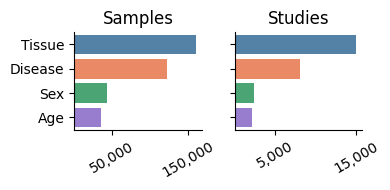

In [ ]:
plot_total_anno_sample_and_study(
    sample_db,
    series_db,
    attributes=["disease", "tissue", "sex", "age"],
    ylabel="",
    figsize=(4, 2),
    titles=["Samples", "Studies"],
    save=True,
    outfile="figures/attribute_sample_and_study_count.svg",
    dpi=1000,
    order=["Tissue", "Disease", "Sex", "Age"],
    ylim_scale=1,
)

# Upset plot

### Format data for upset plot

In [ ]:
def count_entries_per_attribute(records: dict[str, list[str]], title: str):
    """For each attribute, count the number of
    entries (samples or studies) that have at least 
    one annotation to that attribute.
    """
        # show number of samples annotated to any attribute
    print(title)
    print("================")
    for attribute, entries in records.items():
        print(f"{attribute.capitalize()}: {len(entries)}")
    print("================\n")


def record_entries_per_attribute(
    database: dict,
    attributes: list[str],
    tech: Literal["rnaseq", "microarray"],
    verbose: bool = False,
    title: str = "Records",
) -> dict[str, list[str]]:
    """Record the samples that 

    Used as input to `upset_plot()`

    """
    platforms = (
        pl.scan_parquet(PLATFORMS_FILE)
            .filter(pl.col("technology") == tech)
            .select("id")
            .collect()
            .to_series()
    ) 
    records = {attribute: [] for attribute in attributes}
    for entry, anno in database.items():

        platform_ok = False
        if "platform" not in anno["accession_ids"]:
            print(anno)

        for platform in anno["accession_ids"]["platform"].split("||"):
            if platform in platforms:
                platform_ok = True
                break

        if not platform_ok:
            continue

        for attribute in records:
            if attribute in anno:
                records[attribute].append(entry)

    if verbose:
        count_entries_per_attribute(records, title)

    return records

In [ ]:
def upset_plot(
    records: dict[str, list[str]],
    title: str | None = None,
    save: bool = False,
    outfile: str | None = None,
    dpi: int=500,
    ylim: int | None = None
):
    df = from_contents(
        {attribute.capitalize(): records[attribute] for attribute in records}
    )
    ax_dict = UpSet(df).plot()

    if isinstance(title, str):
        plt.title(title, fontsize=12, fontweight="bold")

    if isinstance(ylim, int):
        plt.ylim(0, ylim)

    if save and isinstance(outfile, str):
        plt.savefig(outfile, dpi=dpi)

    plt.show()

In [ ]:
# get attribute sample/study counts

# ========== Sample ============
sample_records_microarray = record_entries_per_attribute(
    sample_db, ATTRIBUTES, verbose=True, title="Sample Records (microarray):", tech="microarray"
)
sample_records_rnaseq = record_entries_per_attribute(
    sample_db, ATTRIBUTES, verbose=True, title="Sample Records (rnaseq):", tech="rnaseq"
)

# ========== Study ============
study_records_microarray = record_entries_per_attribute(
    series_db, ATTRIBUTES, verbose=True, title="Study Records (microarray):", tech="microarray"
)
study_records_rnaseq = record_entries_per_attribute(
    series_db, ATTRIBUTES, verbose=True, title="Study Records (rnaseq):", tech="rnaseq"
)

Sample Records (microarray):
Tissue: 106634
Disease: 75627
Sex: 33978
Age: 26042

Sample Records (rnaseq):
Tissue: 53138
Disease: 46233
Sex: 9170
Age: 8938

Study Records (microarray):
Tissue: 7354
Disease: 3811
Sex: 1172
Age: 815

Study Records (rnaseq):
Tissue: 6225
Disease: 3733
Sex: 857
Age: 1034



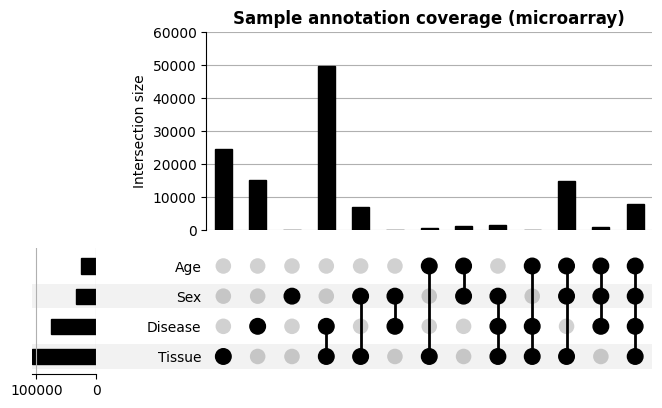

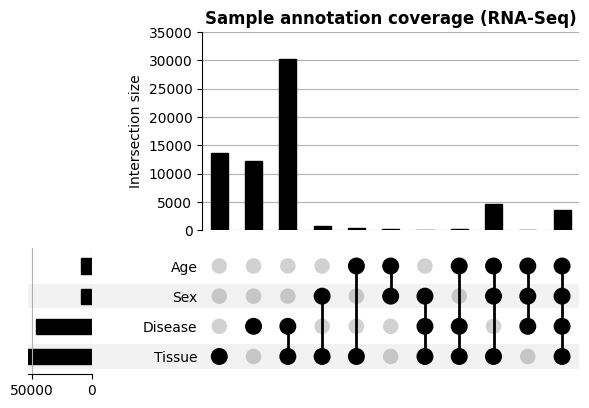

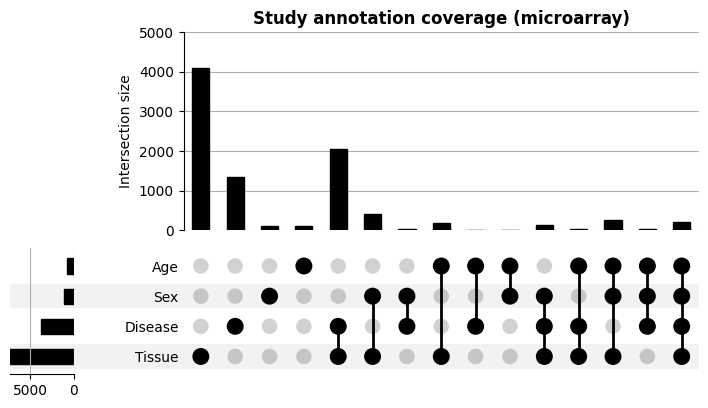

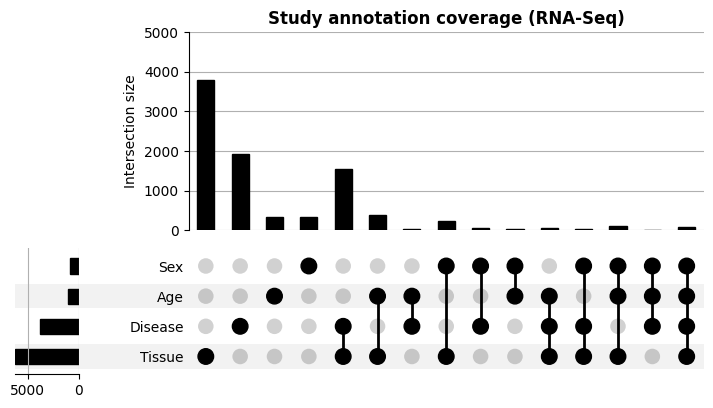

In [ ]:
# upset plots
# Note: there is a bug in the Upsetplot package where pandas v3 raises errors. They're working on a fix: https://github.com/jnothman/UpSetPlot/issues/303, but it is not yet resolved. Use pandas <3.0.0.

with warnings.catch_warnings():
    warnings.simplefilter(action='ignore', category=FutureWarning)
    # ========== Sample ============
    upset_plot(
        sample_records_microarray,
        title="Sample annotation coverage (microarray)",
        save=True,
        outfile=f"figures/attribute_upset_plot__level-sample__tech-microarray.{FMT}",
        dpi=500,
        ylim=60_000,
    )
    upset_plot(
        sample_records_rnaseq,
        title="Sample annotation coverage (RNA-Seq)",
        save=True,
        outfile=f"figures/attribute_upset_plot__level-sample__tech-rnaseq.{FMT}",
        dpi=500,
        ylim=35_000,
    )

    # ========== Study ============
    upset_plot(
        study_records_microarray,
        title="Study annotation coverage (microarray)",
        save=True,
        outfile=f"figures/attribute_upset_plot__level-study__tech-microarray.{FMT}",
        dpi=500,
        ylim=5_000,
    )
    # ========== Study ============
    upset_plot(
        study_records_rnaseq,
        title="Study annotation coverage (RNA-Seq)",
        save=True,
        outfile=f"figures/attribute_upset_plot__level-study__tech-rnaseq.{FMT}",
        dpi=500,
        ylim=5_000
    )

# Get source counts

In [ ]:
def acceptable_platform_sample(entry, ok_platforms):
    if "platform" in entry["accession_ids"]:
        gpl = entry["accession_ids"]["platform"]
        if gpl in ok_platforms:
            return True

    return False

def acceptable_platform_study(entry, ok_platforms):
    if "platform" in entry["accession_ids"]:
        gpls = entry["accession_ids"]["platform"].split("||")
        if len(set(gpls) & set(ok_platforms)) > 0:
            return True

    return False


def get_source_counts(
    database: dict,
    level: Literal["sample", "study"],
    platforms: pl.DataFrame,
):
    platform_mapping_funcs = {"sample": acceptable_platform_sample, "study": acceptable_platform_study}
    is_acceptable_platform = platform_mapping_funcs[level]

    # collect all unique sources across all attributes first
    all_sources = set()
    for id_, data in database.items():
        for attribute in ["tissue", "disease", "sex", "age"]:
            if attribute in data:
                all_sources.update(data[attribute].keys())

    # store results for each technology
    all_results = []
    attributes = ["tissue", "disease", "sex", "age"]

    # count sources for each attribute across all GSM IDs, separated by technology
    for technology in platforms["technology"].unique():
        ok_platforms = platforms.filter(pl.col("technology") == technology)["id"].to_list()

        tissue_sources = defaultdict(int)
        disease_sources = defaultdict(int)
        sex_sources = defaultdict(int)
        age_sources = defaultdict(int)

        for id_, data in database.items():

            if not is_acceptable_platform(data, ok_platforms):
                continue

            # Count tissue sources
            if "tissue" in data:
                for source, source_data in data["tissue"].items():
                    if "id" in source_data:
                        tissue_sources[source] += 1

            # Count disease sources
            if "disease" in data:
                for source, source_data in data["disease"].items():
                    if "id" in source_data:
                        disease_sources[source] += 1

            # Count sex sources
            if "sex" in data:
                for source, source_data in data["sex"].items():
                    if "id" in source_data:
                        sex_sources[source] += 1

            # Count age sources
            if "age" in data:
                for source, source_data in data["age"].items():
                    if "id" in source_data:
                        age_sources[source] += 1

        # Create dataframes for this technology, ensuring all sources appear
        for attribute, source_dict in [
            ("tissue", tissue_sources),
            ("disease", disease_sources),
            ("sex", sex_sources),
            ("age", age_sources)
        ]:
            df = pl.DataFrame(
                {
                    "technology": [technology for _ in all_sources],
                    "attribute": [attribute for _ in all_sources],
                    "source": list(all_sources),
                    "count": [source_dict.get(source, 0) for source in all_sources],
                }
            )
            all_results.append(df)

    return pl.concat(all_results)

In [ ]:
platforms = pl.read_parquet(PLATFORMS_FILE)

sample_source_counts = get_source_counts(sample_db, "sample", platforms)
study_source_counts = get_source_counts(series_db, "study", platforms)

# Plot source counts

In [ ]:
def lighten_color(color, amount=0.5):
    try:
        c = mcolors.to_rgb(color)
    except ValueError:
        c = mcolors.to_rgb(mcolors.cnames[color])
    c = [(1 - amount) * comp + amount for comp in c]
    return c

def plot_source_counts_by_attribute(
    df: pl.DataFrame,
    ylabel: str,
    attributes: list[str],
    figsize: tuple[int, int]=(10, 8),
    title: str = "",
    save: bool=False,
    outfile: str | None = None,
    dpi: int = 500,
    ylim_scale: int = 1,
    verbose: bool = False,
):

    TECHNOLOGY_COLORS = {
        "microarray": "dimgrey",
        "rnaseq": "lightgrey",
    }

    def get_tech_color(tech, base_color):
        if tech == "microarray":
            return base_color
        elif tech == "rnaseq":
            return lighten_color(base_color, amount=0.6)
        else:
            return base_color

    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.flatten()

    technologies = df["technology"].unique().sort().to_list()
    all_sources = sorted(df["source"].unique().to_list())

    for idx, attribute in enumerate(attributes):
        df_filtered = df.filter(pl.col("attribute") == attribute)

        df_plot = df_filtered.with_columns(
            pl.col("source").cast(pl.Enum(all_sources))
        ).sort("source")

        dark_color = COLORS[attribute]
        palette = {tech: get_tech_color(tech, dark_color) for tech in technologies}

        sns.barplot(
            data=df_plot.to_pandas(),
            y="count",
            x="source",
            hue="technology",
            ax=axes[idx],
            palette=palette,
        )

        if axes[idx].get_legend():
            axes[idx].get_legend().remove()

        axes[idx].tick_params(axis='x', rotation=90)
        for label in axes[idx].get_xticklabels():
            label.set_ha('center')
        axes[idx].set_title(f'{attribute.capitalize()}', fontsize=14)
        axes[idx].set_xlabel('', fontsize=12)
        axes[idx].set_ylabel(ylabel, fontsize=12)
        axes[idx].set_ylim(0, (ceil(df_plot['count'].max() / ylim_scale) * ylim_scale))
        axes[idx].grid(axis='y', alpha=0.3)

        axes[idx].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x):,}'))

        sns.despine(ax=axes[idx], top=True, right=True, left=True)

        if verbose:
            print(f"\n{attribute.capitalize()} annotations by technology:")
            for tech in df_filtered["technology"].unique():
                tech_total = df_filtered.filter(pl.col("technology") == tech)["count"].sum()
                print(f"  {tech}: {tech_total:,}")

    legend_elements = [
        Patch(
            facecolor=get_tech_color(tech, "dimgrey"),
            label=tech
        )
        for tech in technologies
    ]

    fig.legend(handles=legend_elements, title='Technology', loc='upper right',
               bbox_to_anchor=(0.98, 0.86), fontsize=10)

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()

    if save and isinstance(outfile, str):
        plt.savefig(outfile, dpi=dpi, bbox_inches="tight")
    plt.show()

## Sample

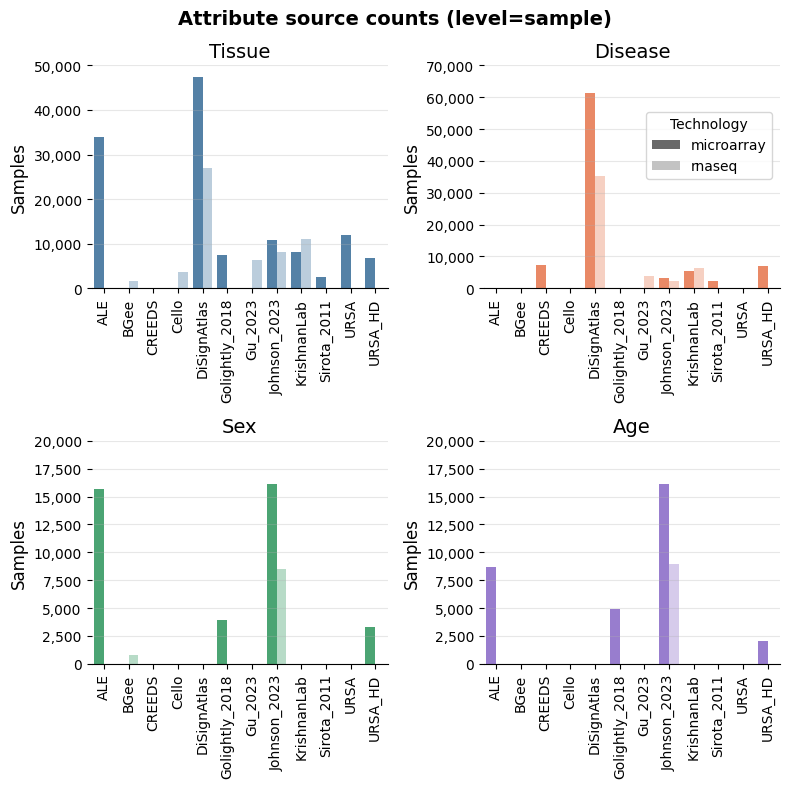

In [ ]:
plot_source_counts_by_attribute(
    sample_source_counts,
    "Samples",
    ATTRIBUTES,
    figsize=(8,8),
    title="Attribute source counts (level=sample)",
    save=True,
    outfile=f"figures/source_counts_by_attribute__level-sample__tech-all.{FMT}",
    dpi=500,
    ylim_scale=10_000,
)

## Study

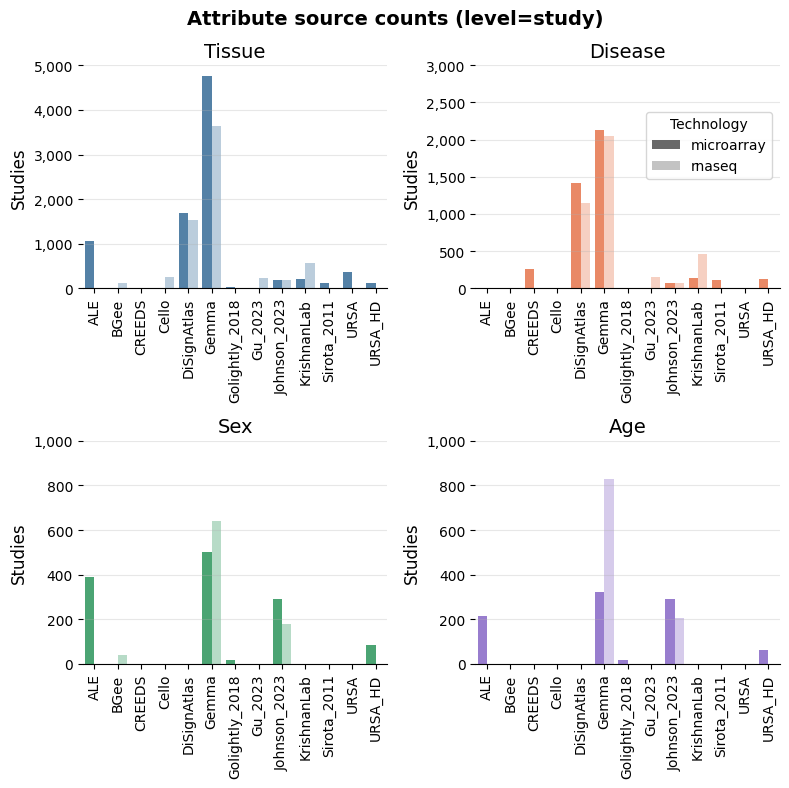

In [ ]:
plot_source_counts_by_attribute(
    study_source_counts,
    "Studies",
    ATTRIBUTES,
    figsize=(8,8),
    title="Attribute source counts (level=study)",
    save=True,
    outfile=f"figures/source_counts_by_attribute__level-study__tech-all.{FMT}",
    dpi=500,
    ylim_scale=1000,
)

## Number of available tissues and diseases

### Direct annotations

In [ ]:
def get_direct_annotations(data: dict, attributes: list[str] = ["tissue", "disease"]):
    direct_annotations = {attribute: set() for attribute in attributes}
    for anno in data.values():
        for attribute in attributes:
            if attribute not in anno:
                continue
            for source in anno[attribute]:
                for entry in anno[attribute][source]["id"].split("|"):
                    direct_annotations[attribute].add(entry)

    return direct_annotations

In [ ]:
sample_tissue_disease_direct_annotations = get_direct_annotations(sample_db)
study_tissue_disease_direct_annotations = get_direct_annotations(series_db)

In [ ]:
unique_tissues = sample_tissue_disease_direct_annotations["tissue"] & study_tissue_disease_direct_annotations["tissue"]
unique_diseases = (sample_tissue_disease_direct_annotations["disease"] & study_tissue_disease_direct_annotations["disease"])

print(f"Number of unique tissues that are directly annotated: {len(unique_tissues)}")
print(f"Number of unique diseases that are directly annotated: {len(unique_diseases)}")

Number of unique tissues that are directly annotated: 667
Number of unique diseases that are directly annotated: 937


### Propagated annotations

In [ ]:
unique_propagated_terms = load_txt(UNIQUE_PROPAGATED_TERMS)

for attribute in ["tissue", "disease"]:

    terms = set()
    for term in unique_propagated_terms:
        if (attribute == "tissue") and (term.startswith("UBERON") or term.startswith("CL")):
            terms.add(term)
        if (attribute == "disease") and (term.startswith("MONDO")):
            terms.add(term)

    print(f"Number of unique {attribute}s in propagated annotations: {len(terms)}")

Number of unique tissues in propagated annotations: 2463
Number of unique diseases in propagated annotations: 2741


# Annotation overlap across sources

In [ ]:
def pmi_from_cooccurrence(x: np.typing.NDArray, method: Literal["positive", "norm"] | None = None):
    """Compute pointwise mutual information for all pairs from a 
    symmetric co-occurrence matrix.

    Arguments:
        x (NDArray):
            2D array-like, symmetric count matrix.
        positive (bool):
            If True, return PPMI.
        method (Literal['positive', 'norm'] | None):
            Compute ppmi or npmi.

    Returns:
        (NDArray): square 2D numpy array of PMI values
    """
    x = np.array(x, dtype=float)
    total = x.sum()
    col_sums = x.sum(axis=1)

    joint = x / total
    outer_marginals = np.outer(col_sums, col_sums) / (total ** 2)

    with np.errstate(divide='ignore', invalid='ignore'):
        pmi = np.where(
            joint > 0,
            np.log2(joint / outer_marginals),
            -np.inf
        )

    if method == "positive":
        pmi = np.maximum(pmi, 0)

    if method == "norm":
        with np.errstate(divide='ignore', invalid='ignore'):
            pmi = np.where(
                joint > 0,
                pmi / -np.log2(joint),
                np.nan
            )

    np.fill_diagonal(pmi, np.nan)
    return pmi

In [ ]:
def match_pattern(text: str, pattern: str) -> str:
    match = re.search(pattern, text)
    if match:
        return match.group(1)
    else:
        return ""


def get_overlap_results(
    dir: Path,
    overlap_type: str,
    level: Literal["sample", "series"],
    attribute_pattern: str = r"attribute-(tissue|disease|sex|age)",
    level_pattern: str = r"level-(sample|series)",
    pmi: bool = False,
    separator="\t",
    **pmi_kwargs,
) -> dict[str, pl.DataFrame]:
    results: dict[str, pl.DataFrame] = {}

    files = list(RESULTS_DIR.glob(f"{overlap_type}*"))

    for file in files:

        file_level = match_pattern(file.stem, level_pattern)
        if file_level != level:
            continue

        attribute = match_pattern(file.stem, attribute_pattern)
        df = pl.read_csv(file, separator=separator)
        if pmi:
            values = pmi_from_cooccurrence(df.to_numpy(), **pmi_kwargs)
            df = pl.DataFrame(values, schema=df.columns)

        results[attribute] = df

    if len(results) == 0:
        print("No files found that met conditions:")
        print(f"Directory: {dir}")
        print(f"Overlap type: {overlap_type}")
        print(f"Level: {level}")
        print(f"Attribute pattern: {attribute_pattern}")
        print(f"Level pattern: {level_pattern}")
        print(f"Files: {files}")
        raise RuntimeError()

    return results

In [ ]:
def plot_overlap_heatmap(
    overlap_results: dict[str, pl.DataFrame],
    subplot_shape: tuple[int, int] = (2, 2),
    figsize_per_plot: tuple[int, int] = (5, 5),
    title: str = "",
    order: list[str] | None = None,
    save: bool = False,
    outfile: Path | str | None = None,
    vmax_percentile: float | int | None = None,
    **heatmap_kwargs,
):
    nrows, ncols = subplot_shape
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_per_plot[0] * ncols, figsize_per_plot[1] * nrows),
    )

    if isinstance(axes, np.ndarray):
        axes_flat = axes.flatten()
    else:
        axes_flat = [axes]

    if isinstance(order, list):
        overlap_results = {k: overlap_results[k] for k in order}

    for ax, (group_name, df) in zip(axes_flat, overlap_results.items()):
        df = (
            df.with_columns(pl.Series("source", df.columns))
            .to_pandas()
            .set_index("source", drop=True)
        )

        if "vmax" not in heatmap_kwargs and (isinstance(vmax_percentile, (int, float))):
            vmax = np.percentile(df.to_numpy(), vmax_percentile)
            sns.heatmap(df, ax=ax, vmax=vmax, **heatmap_kwargs)
        else:
            sns.heatmap(df, ax=ax, **heatmap_kwargs)

        ax.set_title(group_name.capitalize())
        xticks = ax.get_xticklabels()
        ax.set_xticklabels(labels=xticks, rotation=45, ha='right', rotation_mode='anchor')

    for ax in axes_flat[len(overlap_results):]:
        ax.axis("off")

    plt.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()

    if save and isinstance(outfile, (str, Path)):
        plt.savefig(outfile, dpi=400)

    plt.show()

## Sample

### Absolute counts

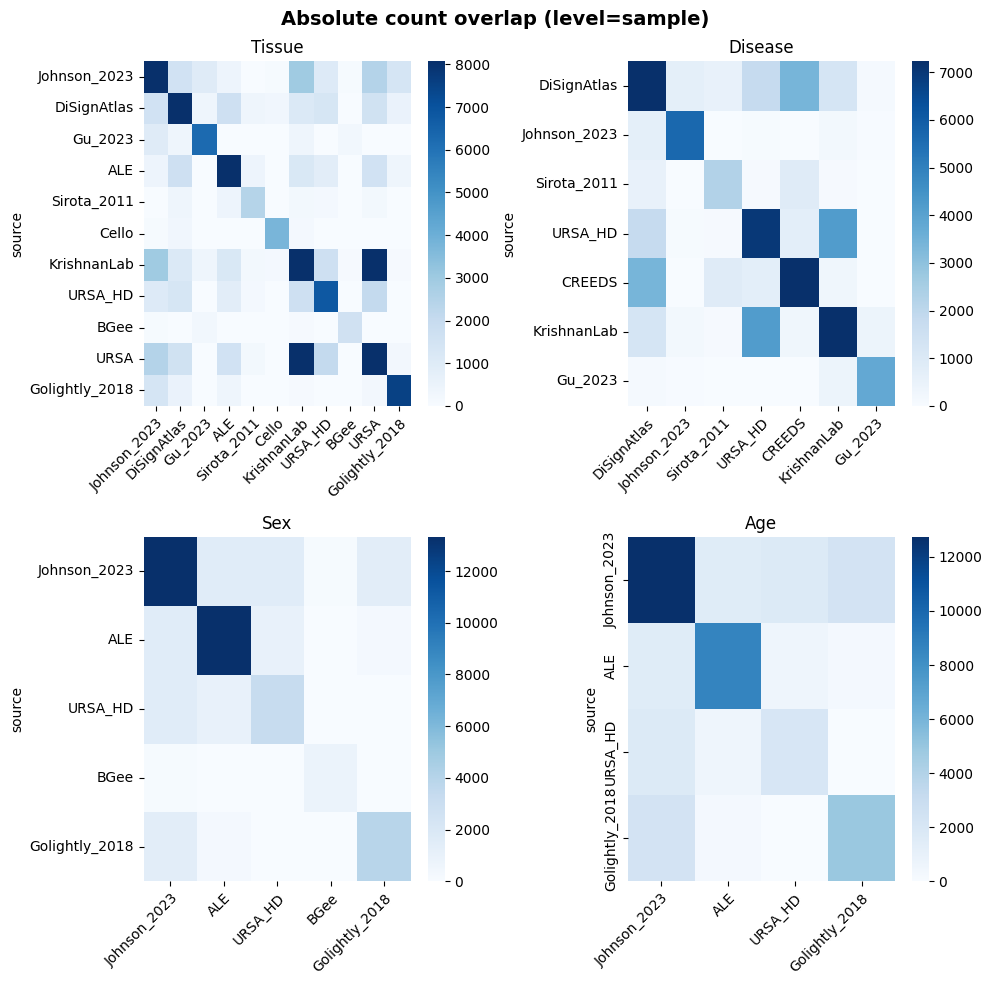

In [ ]:
sample_overlap_count = get_overlap_results(RESULTS_DIR, overlap_type="overlap_count", level="sample")
plot_overlap_heatmap(
    sample_overlap_count,
    order=OVERLAP_ORDER,
    cmap=OVERLAP_CMAP,
    vmax_percentile=95,
    title="Absolute count overlap (level=sample)",
    save=True,
    outfile=FIGURES_DIR / "overlap__level-sample__metric-counts.png"
)

### Percent overlap

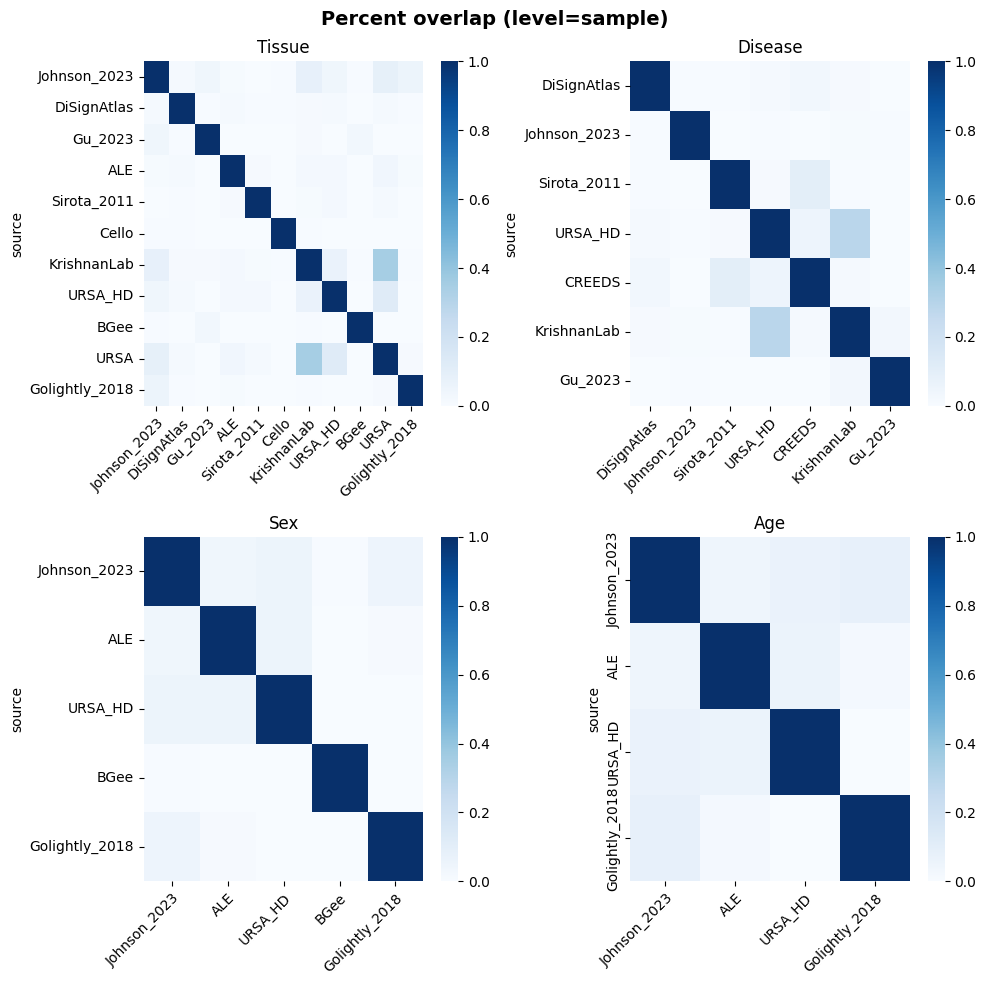

In [ ]:
sample_overlap_percent = get_overlap_results(RESULTS_DIR, overlap_type="overlap_percent", level="sample")
plot_overlap_heatmap(
    sample_overlap_percent,
    order=OVERLAP_ORDER,
    cmap=OVERLAP_CMAP,
    title="Percent overlap (level=sample)",
    save=True,
    outfile=FIGURES_DIR / "overlap__level-sample__metric-percent.png",
    )

### Normalized PMI

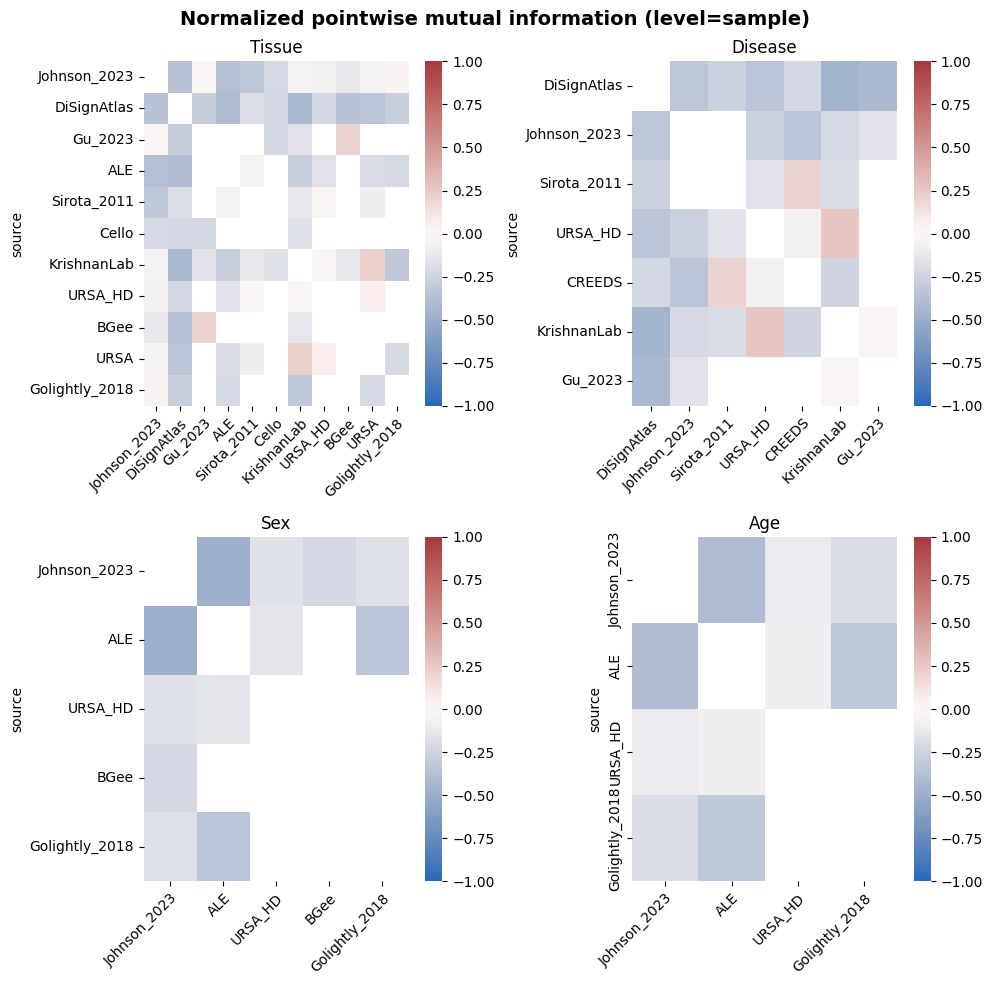

In [ ]:
sample_overlap_pmi = get_overlap_results(
    RESULTS_DIR,
    overlap_type="overlap_count",
    level="sample",
    pmi=True,
    method="norm",
)
plot_overlap_heatmap(
    sample_overlap_pmi,
    order=OVERLAP_ORDER,
    cmap=PMI_CMAP,
    vmax=1,
    vmin=-1,
    title="Normalized pointwise mutual information (level=sample)",
    save=True,
    outfile=FIGURES_DIR / "overlap__level-sample__metric-pmi.png",
)

## Series

### Absolute counts

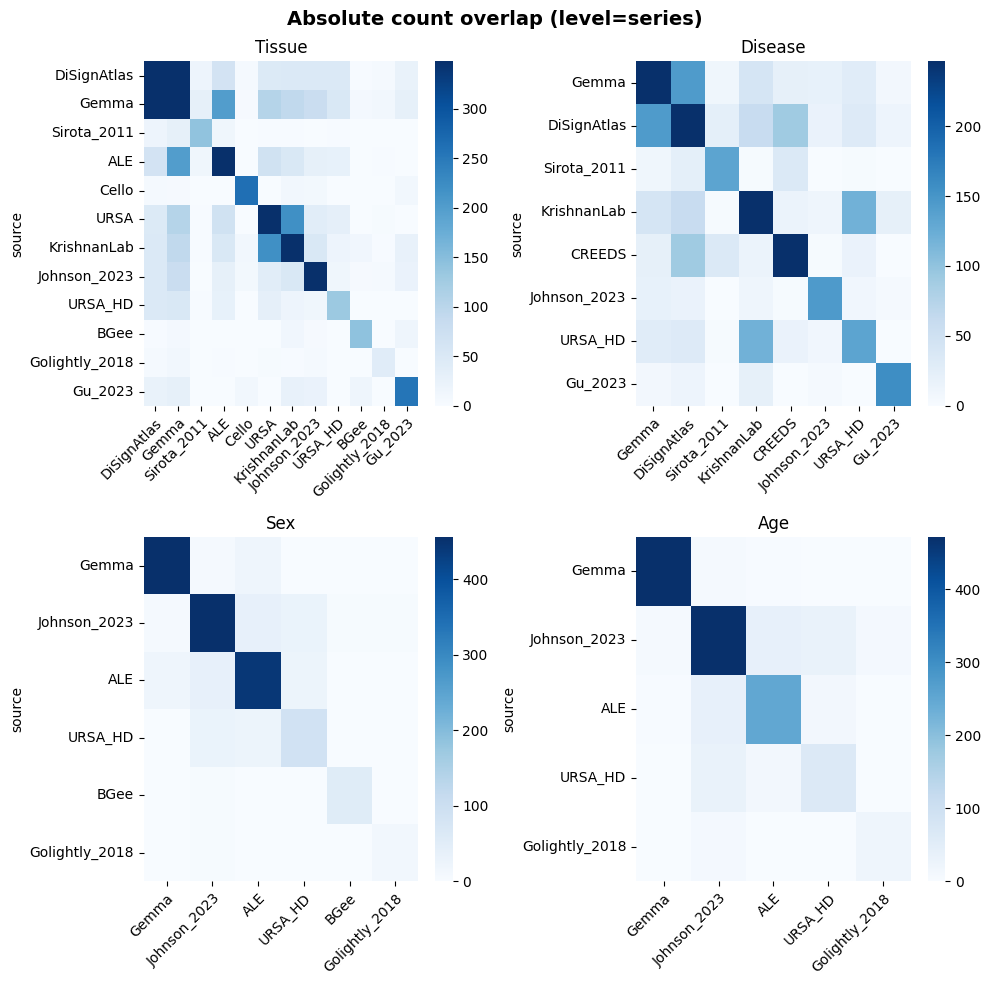

In [ ]:
series_overlap_count = get_overlap_results(
    RESULTS_DIR, overlap_type="overlap_count", level="series"
)
plot_overlap_heatmap(
    series_overlap_count,
    order=OVERLAP_ORDER,
    cmap=OVERLAP_CMAP, 
    vmax_percentile=95,
    title="Absolute count overlap (level=series)",
    save=True,
    outfile=FIGURES_DIR / "overlap__level-series__metric-counts.png",
)

### Percent overlap

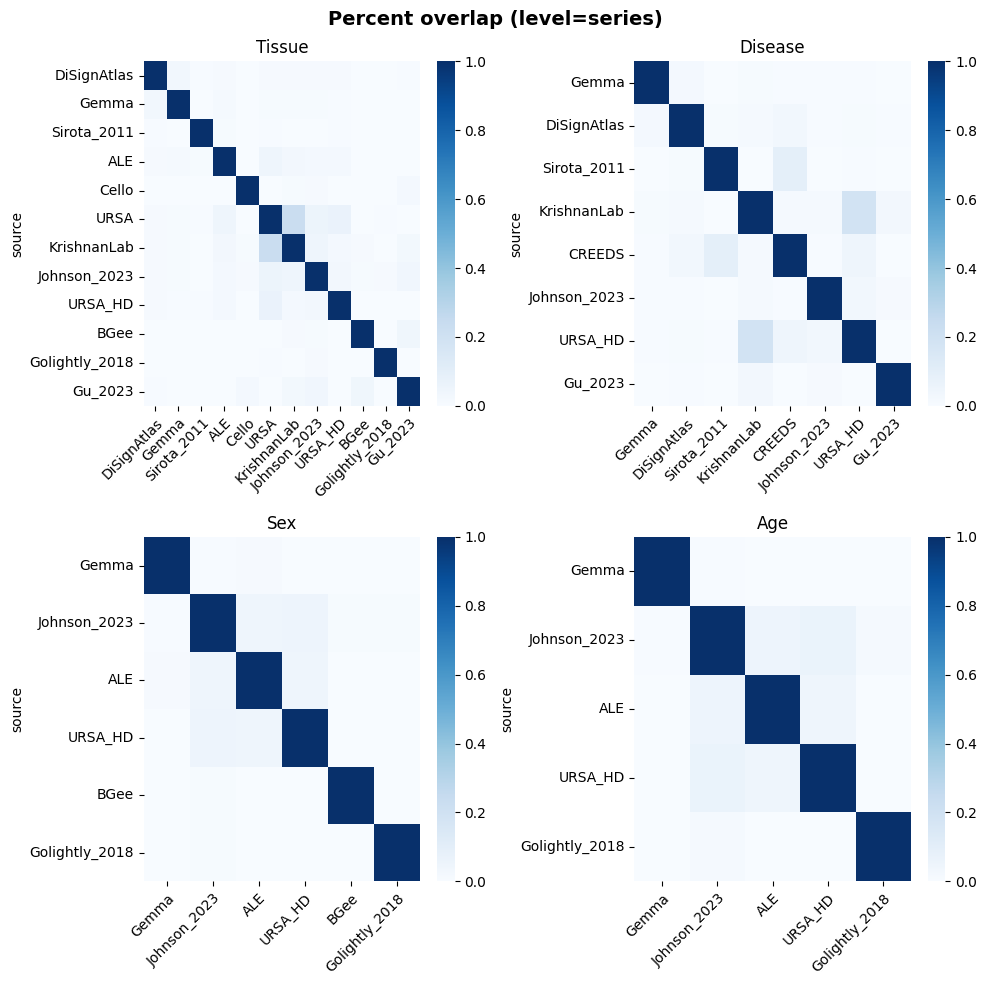

In [ ]:
series_overlap_percent = get_overlap_results(
    RESULTS_DIR, overlap_type="overlap_percent", level="series"
)
plot_overlap_heatmap(
    series_overlap_percent,
    order=OVERLAP_ORDER,
    cmap=OVERLAP_CMAP,
    title="Percent overlap (level=series)",
    save=True,
    outfile=FIGURES_DIR / "overlap__level-series__metric-percent.png",
)

### PMI

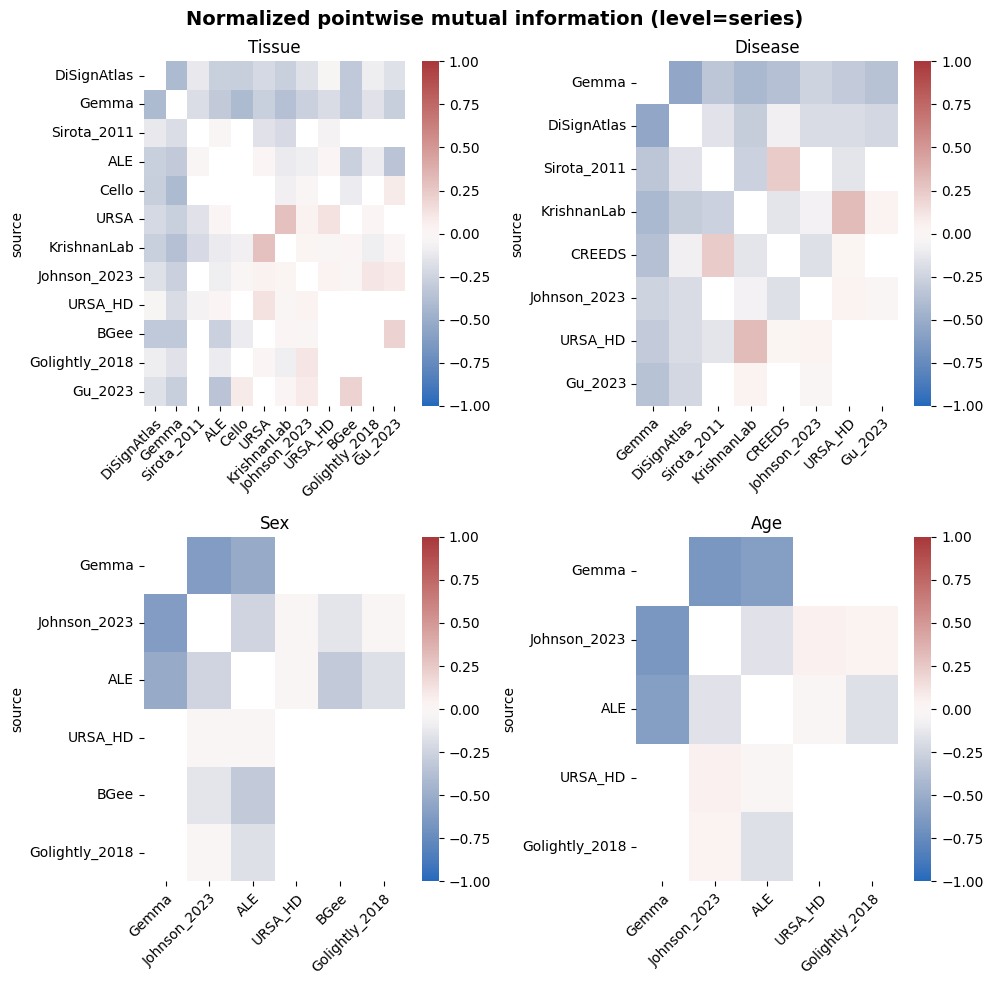

In [ ]:
series_overlap_pmi = get_overlap_results(
    RESULTS_DIR,
    overlap_type="overlap_count",
    level="series",
    pmi=True,
    method="norm"
)
plot_overlap_heatmap(
    series_overlap_pmi,
    order=OVERLAP_ORDER,
    cmap=PMI_CMAP,
    vmax=1,
    vmin=-1,
    title="Normalized pointwise mutual information (level=series)",
    save=True,
    outfile=FIGURES_DIR / "overlap__level-series__metric-pmi.png",
)

# Annotation coverage improvement analysis
The following plots show the annotation coverage improvement for samples and studies post-harmonization. The x-axis represents the total number of samples/studies from a particular annotation source that have an annotation for a particular attribute post-harmonization.

In [ ]:
def collect_db_anno(
    db: dict,
    attributes: list[str],
    entry_prefix: str | tuple[str, ...],
) -> pl.DataFrame:
    results = {"accession": [], "attribute": [], "source": []}
    for entry, contents in db.items():

        if not entry.startswith(entry_prefix):
            continue

        for attribute in attributes:
            if attribute not in contents:
                continue

            for source in contents[attribute]:
                results["accession"].append(entry)
                results["attribute"].append(attribute)
                results["source"].append(source)

    return pl.DataFrame(results).sort(["accession", "source", "attribute"])

In [ ]:
def extract_source_annotation_count_differences(
    raw: pl.DataFrame, new: pl.DataFrame, attributes: list[str], source: str
) -> pl.DataFrame:
    shared_entries = set(
        raw.filter(pl.col("source") == source)
        .join(new, on="accession", how="inner")["accession"]
        .unique()
        .to_list()
    )
    n_shared_entries = len(shared_entries)

    results = {
        "attribute": [],
        "num_old": [],
        "percent_old": [],
        "num_new": [],
        "percent_new": [],
    }
    for attribute in attributes:
        # shared entries that had attribute A annotated from source S (in raw)
        S_A_shared = set(
            raw.filter(
                (pl.col("source") == source)
                & (pl.col("attribute") == attribute)
                & (pl.col("accession").is_in(shared_entries))
            )["accession"]
            .unique()
            .to_list()
        )

        # shared entries that have attribute A annotated from any source in new (O)
        O_A_shared = set(
            new.filter(
                (pl.col("attribute") == attribute)
                & (pl.col("accession").is_in(shared_entries))
                & (~pl.col("accession").is_in(S_A_shared))
            )["accession"]
            .unique()
            .to_list()
        )

        num_old = len(S_A_shared)
        num_new = len(O_A_shared)
        total = num_old + num_new
        percent_old = num_old / total

        num_new = len(O_A_shared)
        percent_new = num_new / total

        results["attribute"].append(attribute)
        results["num_old"].append(num_old)
        results["percent_old"].append(percent_old)
        results["num_new"].append(num_new)
        results["percent_new"].append(percent_new)

    return pl.DataFrame(results)

In [ ]:
def add_missing_attribute_counts(df: pl.DataFrame, col_count: str, attributes: list[str]) -> pl.DataFrame:
    additional_rows = {"attribute": [], col_count: []}
    for attribute in attributes:
        if attribute not in df["attribute"]:
            additional_rows["attribute"].append(attribute)
            additional_rows[col_count].append(0)

    additional_df = pl.DataFrame(additional_rows, schema=df.schema)
    return pl.concat([df, additional_df], how="vertical").sort("attribute")


def _extract_source_annotation_count_differences(
    raw: pl.DataFrame, new: pl.DataFrame, attributes: list[str], source: str
) -> pl.DataFrame:
    shared_entries = set(
        raw.filter(pl.col("source") == source)
        .join(new, on="accession", how="inner")["accession"]
        .unique()
        .to_list()
    )
    n_shared_entries = len(shared_entries)

    results = {
        "attribute": [],
        "num_old": [],
        "percent_old": [],
        "num_new": [],
        "percent_new": [],
    }
    for attribute in attributes:
        # shared entries that had attribute A annotated from source S (in raw)
        S_A_shared = set(
            raw.filter(
                (pl.col("source") == source)
                & (pl.col("attribute") == attribute)
                & (pl.col("accession").is_in(shared_entries))
            )["accession"]
            .unique()
            .to_list()
        )

        # shared entries that have attribute A annotated from any source in new (O)
        O_A_shared = set(
            new.filter(
                (pl.col("attribute") == attribute)
                & (pl.col("accession").is_in(shared_entries))
                & (~pl.col("accession").is_in(S_A_shared))
            )["accession"]
            .unique()
            .to_list()
        )

        num_old = len(S_A_shared)
        percent_old = num_old / n_shared_entries

        num_new = len(O_A_shared)
        percent_new = num_new / n_shared_entries

        results["attribute"].append(attribute)
        results["num_old"].append(num_old)
        results["percent_old"].append(percent_old)
        results["num_new"].append(num_new)
        results["percent_new"].append(percent_new)

    return pl.DataFrame(results)


def extract_annotation_count_differences(
    raw: pl.DataFrame, new: pl.DataFrame, attributes: list[str]
) -> pl.DataFrame:
    results: list[pl.DataFrame] = []
    for source in raw["source"].unique():
        result = extract_source_annotation_count_differences(raw, new, attributes, source=source)
        results.append(
            result.with_columns(pl.lit(source).alias("source"))
        )
    return pl.concat(results, how="vertical")

In [ ]:
def plot_coverage_by_attribute_stacked(
    df: pl.DataFrame,
    attribute_color_map: dict,
    attributes: list[str] = None,
    figsize: tuple[int, int] = (12, 10),
    title: str = "",
    save: bool = False,
    outfile: str | None = None,
    dpi: int = 500,
) -> plt.Figure:

    if attributes is None:
        attributes = df["attribute"].unique(maintain_order=True).to_list()

    sources = sorted(df["source"].unique().to_list())

    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.flatten()

    for idx, attr in enumerate(attributes):
        ax = axes[idx]

        subset_pd = (
            df.filter(pl.col("attribute") == attr)
              .select(["source", "percent_old", "percent_new", "num_old", "num_new"])
              .with_columns(pl.col("source").cast(pl.Enum(sources)))
              .sort("source")
              .to_pandas()
        )

        dark_color = attribute_color_map.get(attr, "dimgrey")
        light_color = lighten_color(dark_color, amount=0.6)

        # pre-harmonization
        sns.barplot(
            data=subset_pd,
            y="source",
            x=subset_pd["percent_old"] + subset_pd["percent_new"],
            color=light_color,
            order=sources,
            orient="h",
            saturation=1.0,
            label="Post-harmonization",
            ax=ax,
        )

        # post-harmonization
        sns.barplot(
            data=subset_pd,
            y="source",
            x="percent_old",
            color=dark_color,
            order=sources,
            orient="h",
            saturation=1.0,
            label="Raw",
            ax=ax,
        )

        # add numbers to bars
        n = len(sources)
        patches = ax.patches
        light_patches = patches[:n]
        dark_patches  = patches[n:]

        tol = 0.01  # tolerance for considering two widths the same

        for light_patch, dark_patch, num_new, num_old in zip(
            light_patches, dark_patches,
            subset_pd["num_new"], subset_pd["num_old"],
        ):
            light_width = light_patch.get_width()
            dark_width  = dark_patch.get_width()
            y_center    = light_patch.get_y() + light_patch.get_height() / 2

            zero_dark  = dark_width < tol
            same_width = abs(light_width - dark_width) < tol

            if zero_dark:
                # only light bar visible: show just num_new to the right
                ax.text(
                    light_width + 0.01, y_center,
                    f"{int(num_new):,}",
                    va="center", ha="left", fontsize=8, color=dark_color,
                )
            elif same_width:
                # percent_new ~ 0%: show num_old in the middle of the dark bar only
                ax.text(
                    dark_width / 2, y_center,
                    f"{int(num_old):,}",
                    va="center", ha="center", fontsize=8, color="white",
                )
            else:
                # normal: num_old in the middle of dark bar, num_new to the right
                ax.text(
                    dark_width / 2, y_center,
                    f"{int(num_old):,}",
                    va="center", ha="center", fontsize=8, color="white",
                )
                ax.text(
                    light_width + 0.01, y_center,
                    f"{int(num_new):,}",
                    va="center", ha="left", fontsize=8, color=dark_color,
                )

        ax.set_xlim(0, 1)
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
        ax.set_xlabel("Coverage", fontsize=12)
        ax.set_ylabel("", fontsize=12)
        ax.set_title(attr.capitalize(), fontsize=14)
        ax.tick_params(axis="y", length=0)
        ax.grid(axis="x", alpha=0.3)
        sns.despine(ax=ax, left=True)

        if ax.get_legend():
            ax.get_legend().remove()

    for idx in range(len(attributes), len(axes)):
        axes[idx].set_visible(False)

    dark_color_fallback = "dimgrey"
    light_color_fallback = lighten_color(dark_color_fallback, amount=0.6)
    legend_elements = [
        mpatches.Patch(facecolor=dark_color_fallback, label="Original source"),
        mpatches.Patch(facecolor=light_color_fallback, label="Post-harmonization"),
    ]

    fig.legend(
        handles=legend_elements,
        title="Coverage",
        loc="upper right",
        bbox_to_anchor=(0.88, 0.4),
        fontsize=10,
    )

    plt.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()

    if save and isinstance(outfile, (str, Path)):
        fig.savefig(outfile, dpi=dpi, bbox_inches="tight")

    plt.show()

## Get pre-harmonized annotations.

These are annotations that have been formatted into the same schema. Some annotations from the original sources have been removed based on our inclusion criteria:

* If an annotation can map to UBERON/CL (tissue), MONDO (diseas´), M/F (sex), or an age group (age) either autonomously or manually.
* Annotations to very high level tissue or disease terms (e.g., anatomical system) since we posit that these are not informative annotations and are essentially equivalent to not having an annotation.
* If an entry accession ID cannot be mapped to a GEO accession ID.
* If annotations are for an entry that is not from microarray or RNA-Seq.

In [ ]:
# geo_anno contains annotations from sources that provided annotations for GEO accession IDs.
geo_anno = load_bson(GEO_PROCESSED)
geo_anno = collect_db_anno(geo_anno, ATTRIBUTES, entry_prefix="GSM")

# sra_anno contains annotations from sources that provided from annotations for SRA accession
# IDs, but are now mapped to GEO IDs.
sra_anno = load_bson(SRA_PROCESSED)
sra_anno = collect_db_anno(sra_anno, ATTRIBUTES, entry_prefix="GSM")

# convert dictionary format to DataFrame - sample
raw_sample_df = pl.concat([geo_anno, sra_anno], how="vertical").unique() 
new_sample_df = (
    collect_db_anno(sample_db, ATTRIBUTES, entry_prefix="GSM")
        .unique(["accession", "attribute", "source"])
)

# convert dictionary format to DataFrame - series
raw_series_df = collect_db_anno(load_bson(SEMI_PROCESSED_SERIES), ATTRIBUTES, entry_prefix="GSE")
new_series_df = (
    collect_db_anno(series_db, ATTRIBUTES, entry_prefix="GSE")
        .unique(["accession", "attribute", "source"])
)

In [ ]:
# get count differences between the pre- and post-harmonized annotations
source_harmonization_improvements_sample = extract_annotation_count_differences(
    raw_sample_df, new_sample_df, ATTRIBUTES
)
source_harmonization_improvements_series = extract_annotation_count_differences(
    raw_series_df, new_series_df, ATTRIBUTES
)

## Plots

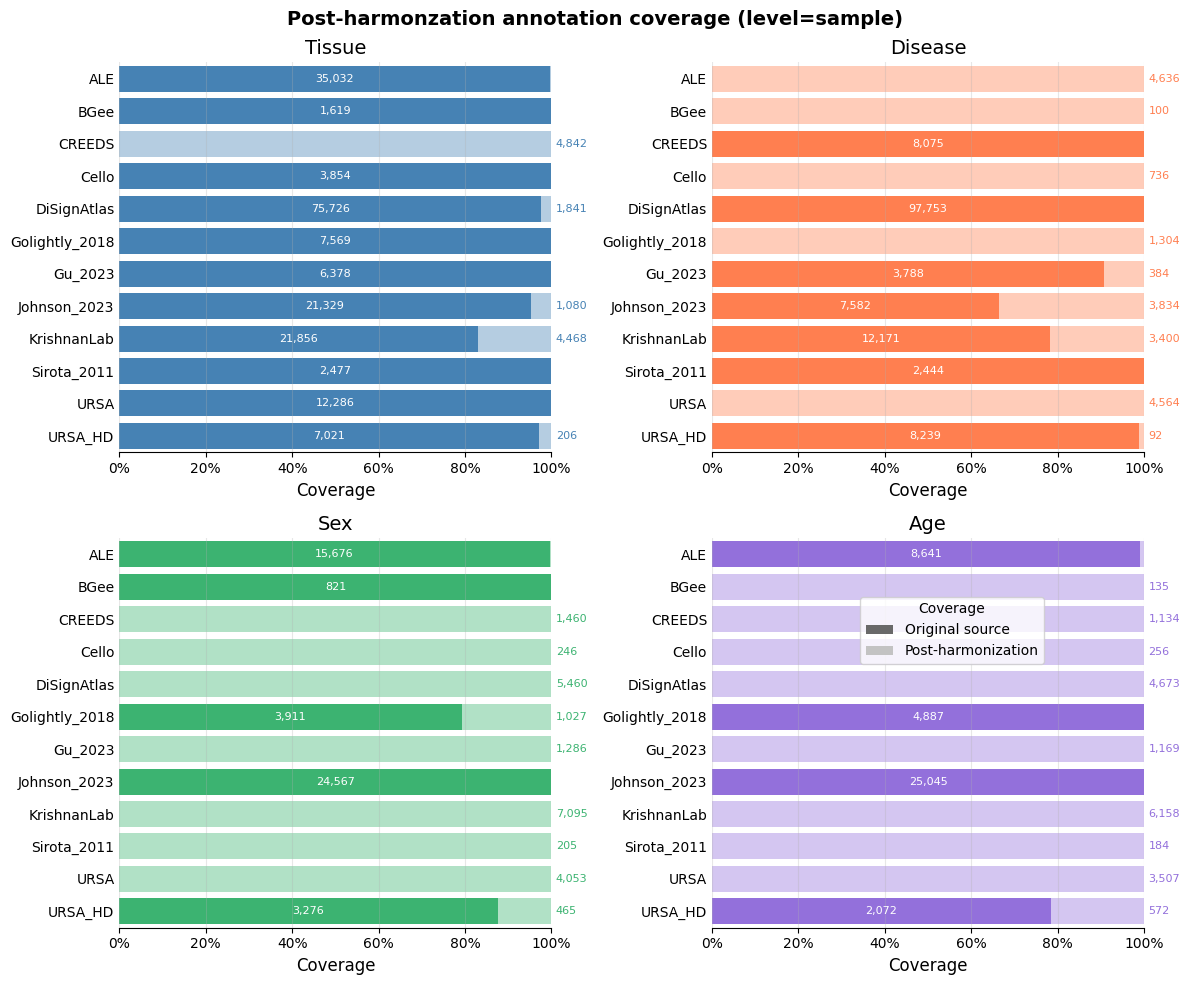

In [ ]:
# plot sample
plot_coverage_by_attribute_stacked(
    source_harmonization_improvements_sample,
    COLORS,
    ATTRIBUTES,
    title="Post-harmonzation annotation coverage (level=sample)",
    save=True,
    outfile = FIGURES_DIR / "annotation_coverage_improvements_by_source__level-sample.png",
)

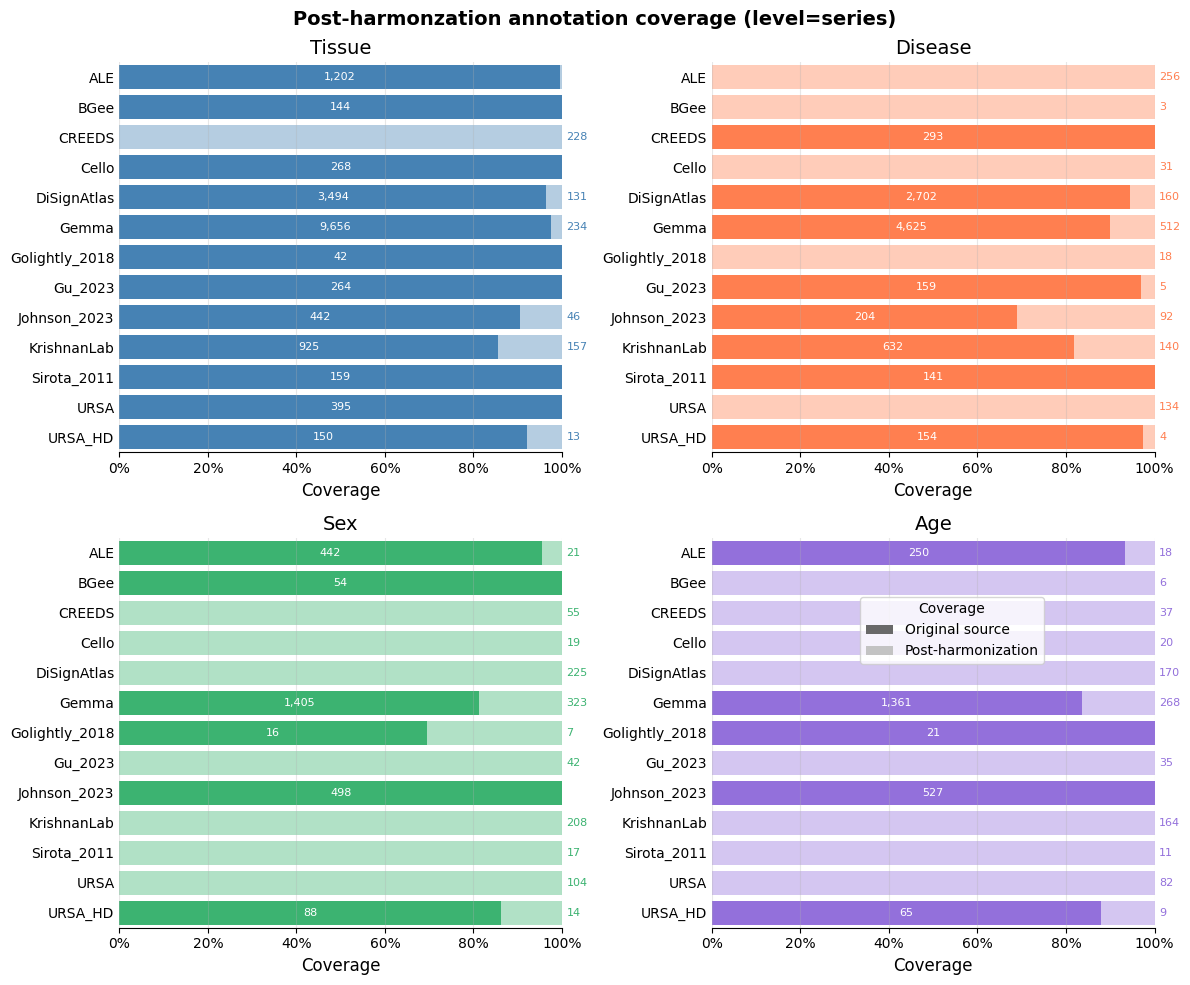

In [ ]:
# plot series
plot_coverage_by_attribute_stacked(
    source_harmonization_improvements_series,
    COLORS,
    ATTRIBUTES,
    title="Post-harmonzation annotation coverage (level=series)",
    save=True,
    outfile = FIGURES_DIR / "annotation_coverage_improvements_by_source__level-series.png",
)